In [29]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

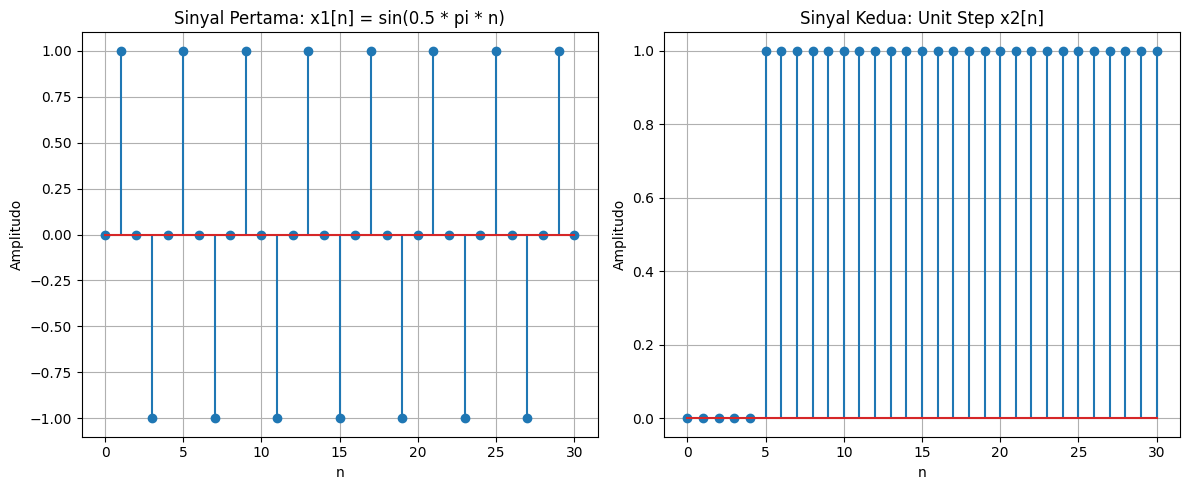

In [30]:
n = np.arange(0, 31) # n = 0, 1, 2, ..., 30

x1 = np.sin(0.5 * np.pi * n)
x2 = np.where(n < 5, 0, 1)

plt.figure(figsize=(12, 5))
#1
plt.subplot(1, 2, 1)
plt.stem(n, x1)
plt.title('Sinyal Pertama: x1[n] = sin(0.5 * pi * n)')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.grid(True)
#2
plt.subplot(1, 2, 2)
plt.stem(n, x2)
plt.title('Sinyal Kedua: Unit Step x2[n]')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.grid(True)

plt.tight_layout()
plt.show()

# Eksperimen Operasi Dasar pada Sinyal dan Citra
Hardi Yusuf Turyasa

Project ini adalah implementasi berbasis Python untuk menerapkan operasi dasar pada sinyal 1D dan citra 2D. Eksperimen ini mencakup operasi penjumlahan, penggeseran (shift), dan amplifikasi, serta pengujian sifat homogenitas dan additivitas untuk menentukan apakah suatu sistem bersifat linier. Tujuan utamanya adalah untuk menganalisis efek operasi-operasi tersebut secara teknis dan konseptual dalam konteks Pengolahan Sinyal Digital.

## Library
* **NumPy:** Untuk komputasi numerik dan pembuatan sinyal diskrit.
* **Matplotlib:** Untuk visualisasi plot sinyal 1D dan histogram citra.
* **OpenCV / PIL:** Untuk membaca, memanipulasi, dan memproses citra 2D.

## Cara Menjalankan Notebook
1. Pastikan Python 3.x sudah terinstal di sistem Anda.
2. Clone repository ini: `git clone https://github.com/Reyhanaku/operasi-dasar-sinyal-citra`
3. Instal semua library yang dibutuhkan dengan menjalankan perintah: `pip install -r requirements.txt`
4. Buka Jupyter Notebook atau Google Colab.
5. Buka dan jalankan seluruh *cell* pada file `notebook/operasi_sinyal_citra.ipynb`.

## Struktur Folder Project
```text
operasi-dasar-sinyal-citra/
|-- notebook/
|   |-- operasi_sinyal_citra.ipynb
|-- images/
|   |-- citra_yang_digunakan.jpg
|-- report/
|   |-- laporan.pdf
|-- README.md
|-- requirements.txt

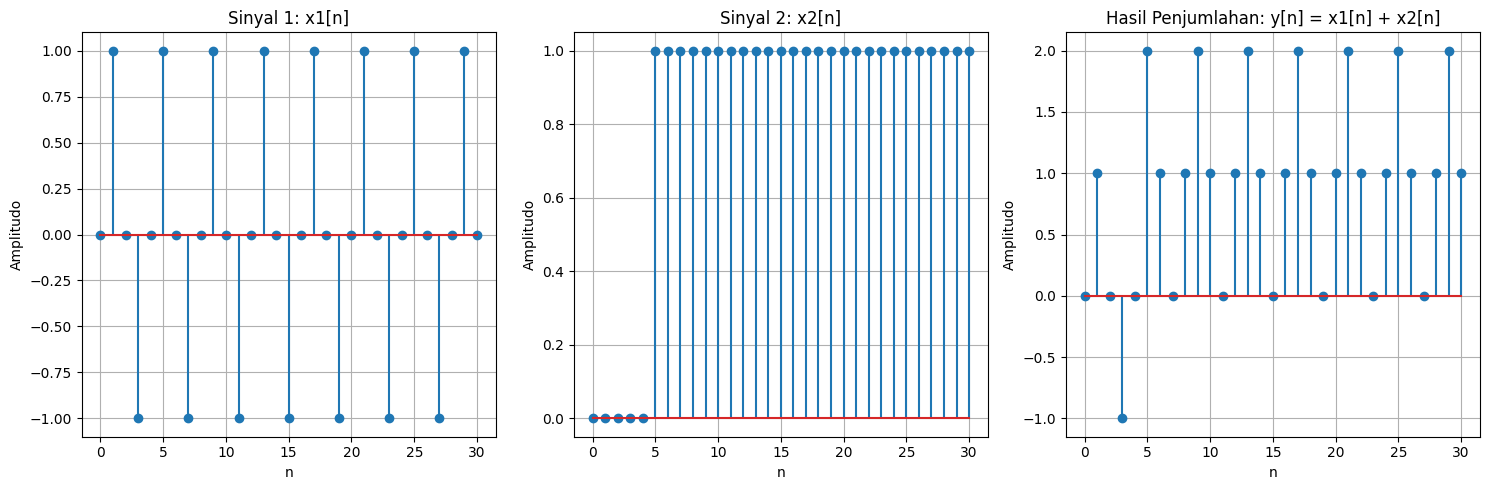

In [31]:
# OPERASI PENJUMLAHAN SINYAL
# Menjumlahkan kedua sinyal
y = x1 + x2

plt.figure(figsize=(15, 5))

# Sinyal 1
plt.subplot(1, 3, 1)
plt.stem(n, x1)
plt.title('Sinyal 1: x1[n]')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.grid(True)

# Sinyal 2
plt.subplot(1, 3, 2)
plt.stem(n, x2)
plt.title('Sinyal 2: x2[n]')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.grid(True)

# Hasil Penjumlahan
plt.subplot(1, 3, 3)
plt.stem(n, y)
plt.title('Hasil Penjumlahan: y[n] = x1[n] + x2[n]')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.grid(True)

plt.tight_layout()
plt.show()

Analisis Hasil Penjumlahan Sinyal ($y[n]$):
1. Perubahan Amplitudo: Pada rentang $n < 5$, amplitudo sinyal $y[n]$ sama persis dengan $x_1[n]$ karena nilai $x_2[n]$ masih 0. Namun, mulai dari $n \ge 5$, amplitudo sinyal $y[n]$ secara keseluruhan mengalami kenaikan sebesar 1 satuan. Ini terjadi karena sinyal sinusoidal tersebut "ditambahkan" ke atas nilai unit step yang bernilai 1.

2. Bentuk Sinyal: Bentuk sinyal hasil penjumlahan merupakan gabungan dari keduanya. Sinyal tersebut masih mempertahankan bentuk osilasi bergelombang khas sinyal asal $x_1[n]$ (sinusoidal), namun poros osilasinya atau level DC offset-nya telah bergeser ke atas mengikuti pola step dari sinyal $x_2[n]$.

3. Aplikasi di Kasus Nyata: Dalam dunia nyata, operasi penjumlahan sinyal ini sangat umum digunakan untuk proses audio mixing (menggabungkan vokal dan instrumen menjadi satu track), menambahkan efek suara, menyisipkan DC offset pada sinyal AC, atau dapat juga merepresentasikan masuknya gangguan (noise) tambahan pada sinyal informasi utama. 

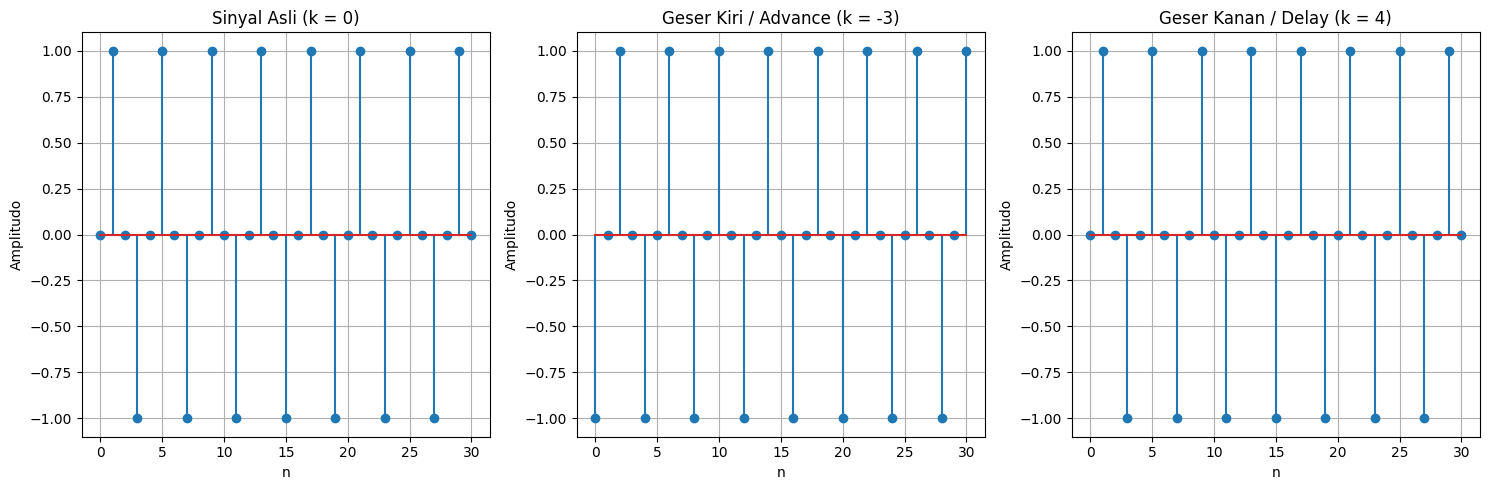

In [32]:
# OPERASI PENGGESERAN SINYAL ---
k_values = [0, -3, 4] 
plt.figure(figsize=(15, 5))

for i, k in enumerate(k_values):
    # Persamaan penggeseran: y[n] = x[n-k]
    # Karena x[n] = sin(0.5 * pi * n), maka x[n-k] = sin(0.5 * pi * (n - k))
    y_shift = np.sin(0.5 * np.pi * (n - k))
    
    plt.subplot(1, 3, i+1)
    plt.stem(n, y_shift)
    
    if k == 0:
        plt.title(f'Sinyal Asli (k = {k})')
    elif k > 0:
        plt.title(f'Geser Kanan / Delay (k = {k})')
    else:
        plt.title(f'Geser Kiri / Advance (k = {k})')
        
    plt.xlabel('n')
    plt.ylabel('Amplitudo')
    plt.grid(True)

plt.tight_layout()
plt.show()

Analisis Operasi Penggeseran Sinyal:

1. Perbedaan Efek $k$ Positif dan $k$ Negatif:  Jika nilai $k$ positif (misal $k = 4$), sinyal akan bergeser ke arah kanan pada sumbu waktu $n$. Ini berarti sinyal mengalami penundaan (delay). Sebaliknya, jika nilai $k$ negatif (misal $k = -3$), sinyal bergeser ke arah kiri, yang berarti sinyal datang lebih awal (advance).

2. Simulasi Delay:  Dalam pemrosesan sinyal diskrit, waktu direpresentasikan oleh indeks sampel $n$. Menggeser sinyal dengan $k$ positif ($x[n-k]$) secara matematis sama dengan menahan sinyal tersebut selama $k$ sampel sebelum dipancarkan atau diproses. Ini sangat akurat untuk mensimulasikan waktu tempuh atau delay perambatan sinyal di dunia nyata, seperti pantulan suara (gema) atau latensi jaringan.

3. Pentingnya Time Alignment:  Time alignment (penyelarasan waktu) sangat krusial agar beberapa sinyal berada pada fase atau titik waktu referensi yang sama. Contohnya, pada sistem mikrofon ganda, suara mungkin tiba di satu mikrofon lebih lambat dari yang lain. Tanpa menggeser sinyal (melakukan time alignment) untuk menyejajarkannya, menjumlahkan kedua sinyal tersebut dapat menyebabkan interferensi destruktif (suara saling menghilangkan atau melemah). 

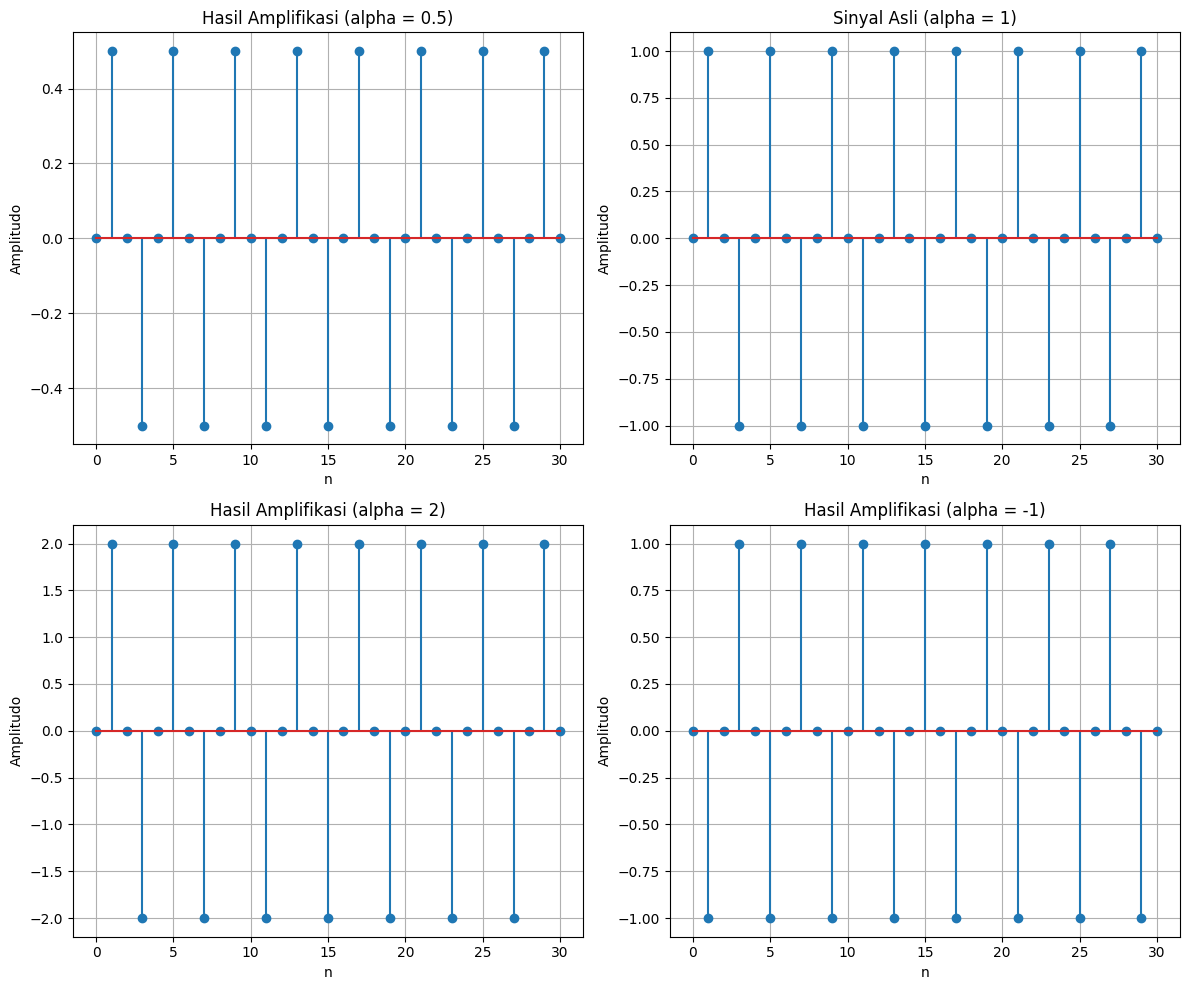

In [33]:
# OPERASI AMPLIFIKASI SINYAL
# Nilai alpha yang diminta: 0.5, 1, 2, dan -1
alphas = [0.5, 1, 2, -1] 

plt.figure(figsize=(12, 10))

for i, alpha in enumerate(alphas):
    y_amp = alpha * x1
    
    plt.subplot(2, 2, i+1)
    plt.stem(n, y_amp)
    
    if alpha == 1:
        plt.title(f'Sinyal Asli (alpha = {alpha})')
    else:
        plt.title(f'Hasil Amplifikasi (alpha = {alpha})')
        
    plt.xlabel('n')
    plt.ylabel('Amplitudo')
    plt.grid(True)

plt.tight_layout()
plt.show()

Nilai α           Efek terhadap Sinyal

0.5               Amplitudo sinyal menyusut menjadi setengah dari ukuran aslinya (mengalami atenuasi atau pelemahan).

1                 Sinyal tetap pada kondisi aslinya (tidak ada perubahan amplitudo).

2                 Amplitudo sinyal membesar menjadi dua kali lipat dari aslinya (mengalami penguatan).

-1               "Amplitudo sinyal tetap sama ukurannya, tetapi fasa sinyal terbalik (inversi). Puncak positif menjadi lembah negatif, dan sebaliknya."

Jawaban Pertanyaan Analisis:

1. Ketika $\alpha > 1$: Sinyal mengalami penguatan (amplifikasi). Puncak gelombang akan semakin tinggi dan lembah akan semakin dalam. (Catatan: Jika soal tertulis $\alpha > 17$, maka penguatannya sangat ekstrem, yaitu 17 kali lipat lebih besar).

2. Ketika $0 < \alpha < 1$: Sinyal mengalami pelemahan (atenuasi). Sinyal akan tampak lebih "pendek" atau menyusut secara vertikal mendekati angka nol.

3. Ketika $\alpha$ negatif: Sinyal mengalami pembalikan fasa (inversi) atau dicerminkan terhadap sumbu horizontal. Nilai positif menjadi negatif, dan sebaliknya.

4. Kaitan dengan Gain Sistem Audio: Dalam sistem audio, konsep amplifikasi ini persis sama dengan parameter Gain atau Volume. Jika kita menaikkan gain ($\alpha > 1$), suara akan terdengar lebih keras. Jika menurunkan gain ($0 < \alpha < 1$), suara menjadi lebih pelan. Jika $\alpha$ negatif, ini mirip dengan membalikkan polaritas kabel speaker, yang sering dilakukan untuk menghindari pembatalan fasa (phase cancellation) pada konfigurasi banyak mikrofon.  

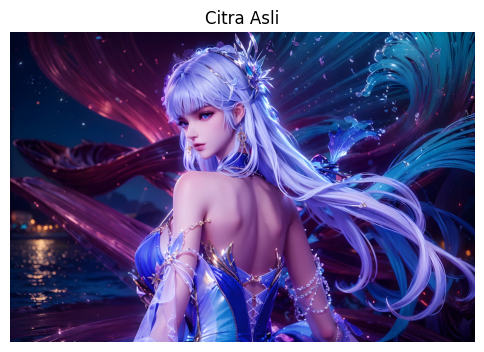

--- INFORMASI CITRA ---
1. Ukuran Citra         : (2048, 3072, 3) (Tinggi, Lebar, Channel)
2. Tipe Data Citra      : uint8
3. Nilai Minimum Pixel  : 0
4. Nilai Maksimum Pixel : 255


In [34]:
# MEMBACA DAN MENAMPILKAN CITRA
image_path = '../images/citra_yang_digunakan.jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    print("ERROR: Gambar tidak ditemukan! Pastikan file 'citra_yang_digunakan.jpg' ada di dalam folder 'images/'.")
else:
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    ukuran_citra = img_rgb.shape
    tipe_data = img_rgb.dtype
    nilai_min = img_rgb.min()
    nilai_max = img_rgb.max()

    # VISUALISASI
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.title('Citra Asli')
    plt.axis('off')
    plt.show()

    # OUTPUT WAJIB
    print("--- INFORMASI CITRA ---")
    print(f"1. Ukuran Citra         : {ukuran_citra} (Tinggi, Lebar, Channel)")
    print(f"2. Tipe Data Citra      : {tipe_data}")
    print(f"3. Nilai Minimum Pixel  : {nilai_min}")
    print(f"4. Nilai Maksimum Pixel : {nilai_max}")

Informasi Citra yang Digunakan:
Pada eksperimen ini, digunakan sebuah citra digital RGB. Berdasarkan ekstraksi data, citra ini menggunakan tipe data uint8 (Unsigned Integer 8-bit), yang merupakan standar umum untuk citra digital di mana setiap saluran warna (Red, Green, Blue) memiliki rentang nilai pixel dari 0 (paling gelap) hingga 255 (paling terang).

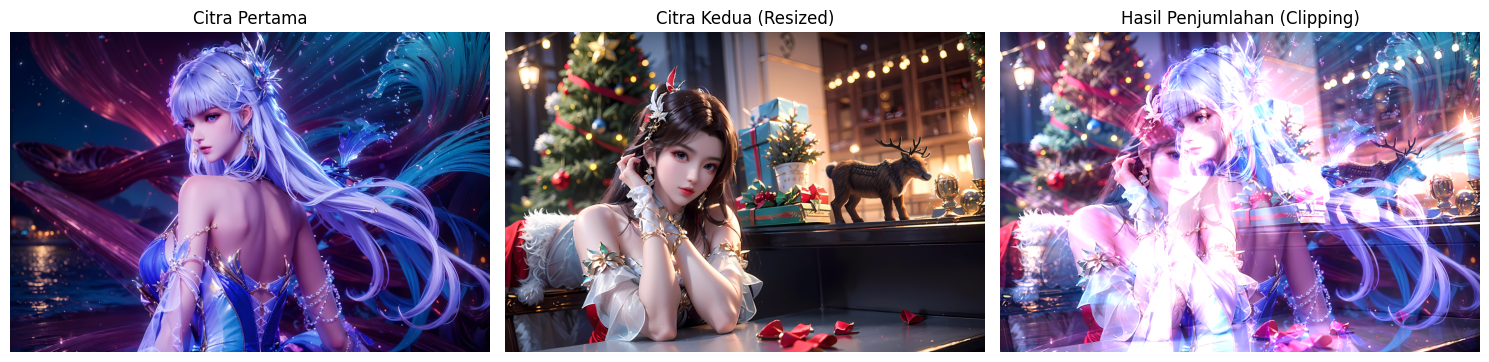

In [35]:
# OPERASI PENJUMLAHAN CITRA
import urllib.request
import os

# 1. Membaca kedua citra
img1 = cv2.imread('../images/citra_yang_digunakan.jpg')
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

img2 = cv2.imread('../images/citra_kedua.jpg')
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# 2. Melakukan Resizing
# Menyamakan ukuran citra kedua dengan citra pertama
dimensi_img1 = (img1.shape[1], img1.shape[0]) 
img2_resized = cv2.resize(img2, dimensi_img1)

# 3. Menjumlahkan citra: I(i, j) = I_1(i, j) + I_2(i, j)
# Kita menggunakan cv2.add() yang secara otomatis melakukan 'clipping' 
img_hasil = cv2.add(img1, img2_resized)

# VISUALISASI
plt.figure(figsize=(15, 5))

# Plot Citra Pertama
plt.subplot(1, 3, 1)
plt.imshow(img1)
plt.title('Citra Pertama')
plt.axis('off')

# Plot Citra Kedua (setelah resize)
plt.subplot(1, 3, 2)
plt.imshow(img2_resized)
plt.title('Citra Kedua (Resized)')
plt.axis('off')

# Plot Citra Hasil Penjumlahan
plt.subplot(1, 3, 3)
plt.imshow(img_hasil)
plt.title('Hasil Penjumlahan (Clipping)')
plt.axis('off')

plt.tight_layout()
plt.show()

Analisis Proses dan Efek Penjumlahan:

* Penjelasan Resizing: Resizing dilakukan pada citra kedua menggunakan fungsi cv2.resize() agar lebar dan tingginya persis sama dengan citra pertama. Hal ini merupakan syarat mutlak sebelum melakukan operasi matematika antar-matriks citra.
* Efek Penjumlahan: Penggabungan dua citra secara langsung mengakibatkan tingkat brightness (kecerahan) citra meningkat drastis. Beberapa area terlihat kehilangan detail karena warnanya berubah menjadi putih pekat (akibat nilai pixel mencapai batas maksimum).  Jawaban Pertanyaan Analisis:

1. Mengapa ukuran citra harus sama? Karena citra digital direpresentasikan sebagai matriks dua dimensi (atau 3D untuk warna). Operasi penjumlahan citra adalah penjumlahan elemen-per-elemen matriks pada koordinat yang sama $(i, j)$. Jika dimensinya berbeda, matriks tersebut tidak bisa dijumlahkan secara matematis.

2. Apa yang terjadi jika melebihi batas maksimum? Jika hasilnya melebihi nilai maksimal (255 untuk format 8-bit), akan terjadi dua kemungkinan tergantung metodenya : bisa terjadi efek overflow (nilainya memutar kembali ke angka 0 menjadi hitam), atau nilainya akan ditahan/dipotong tepat di angka batas maksimum 255 menjadi putih (disebut metode clipping).

3. Perbedaan Clipping dan Normalisasi: Clipping memotong paksa nilai yang berlebih agar mentok di angka 255, sehingga citra terlihat overexposed dan detail warna hilang. Sedangkan normalisasi akan melakukan scaling (skala ulang) rentang nilai keseluruhan agar pas masuk ke 0-255 secara proporsional, sehingga detail citra dan kontras aslinya masih dapat diselamatkan.

4. Aplikasi Nyata: Dalam dunia nyata, operasi ini sering digunakan untuk image blending (membuat efek double exposure dalam fotografi) , menggabungkan gambar medis (seperti scan MRI dan CT), menyisipkan watermark, atau teknik noise reduction dengan cara menjumlahkan dan merata-rata beberapa foto sekaligus.

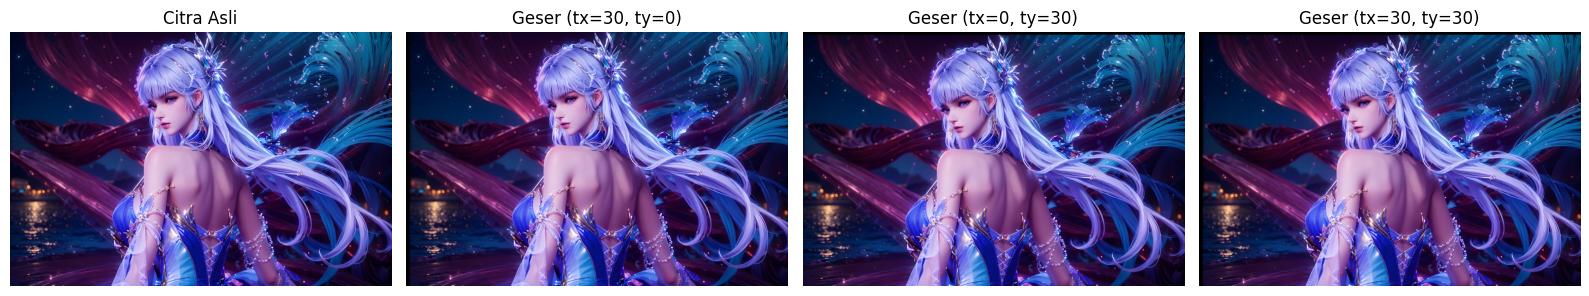

In [36]:
# OPERASI TRANSLASI
import numpy as np

tinggi, lebar = img1.shape[:2]
shifts = [
    (30, 0),   # Geser kanan 30 pixel
    (0, 30),   # Geser bawah 30 pixel
    (30, 30)   # Geser kanan 30 pixel & bawah 30 pixel
]
plt.figure(figsize=(16, 4))

# Citra Asli
plt.subplot(1, 4, 1)
plt.imshow(img1)
plt.title('Citra Asli')
plt.axis('off')

# Lakukan penggeseran dan plot hasilnya
for idx, (tx, ty) in enumerate(shifts):
    # Matriks transformasi M = [[1, 0, tx], [0, 1, ty]]
    M = np.float32([[1, 0, tx], [0, 1, ty]])
    
    # Melakukan penggeseran
    img_shifted = cv2.warpAffine(img1, M, (lebar, tinggi))
    
    plt.subplot(1, 4, idx + 2)
    plt.imshow(img_shifted)
    plt.title(f'Geser (tx={tx}, ty={ty})')
    plt.axis('off')

plt.tight_layout()
plt.show()

Analisis Area Kosong:

Setelah citra digeser, muncul area kosong (berwarna hitam) pada sisi yang ditinggalkan. Area ini muncul karena nilai pixel pada koordinat tersebut kosong akibat pergeseran, sehingga algoritma warpAffine secara default mengisinya dengan nilai pixel 0 (hitam).  

Jawaban Pertanyaan Analisis:

1. Efek Penggeseran terhadap Objek: Penggeseran memindahkan posisi seluruh koordinat objek dalam citra ke arah tertentu (atas, bawah, kiri, atau kanan) sesuai dengan nilai vektor translasinya ($\Delta i$ dan $\Delta j$). Bentuk dan warna objek tetap sama, hanya letaknya saja yang berubah di dalam kanvas citra.

2. Penggunaan Translasi dalam Augmentasi Data: Dalam Machine Learning atau deteksi objek, translasi sangat berguna untuk augmentasi data. Algoritma dilatih menggunakan gambar objek yang posisinya digeser-geser agar model tersebut belajar mengenali objek tanpa bergantung pada lokasi objek di dalam frame (meningkatkan translation invariance).

3. Risiko Penggeseran Terlalu Besar: Jika pergeseran terlalu besar, objek utama (Region of Interest) dalam citra akan terpotong (cropped) dan keluar dari batas layar. Akibatnya, informasi penting dalam citra tersebut akan hilang selamanya.

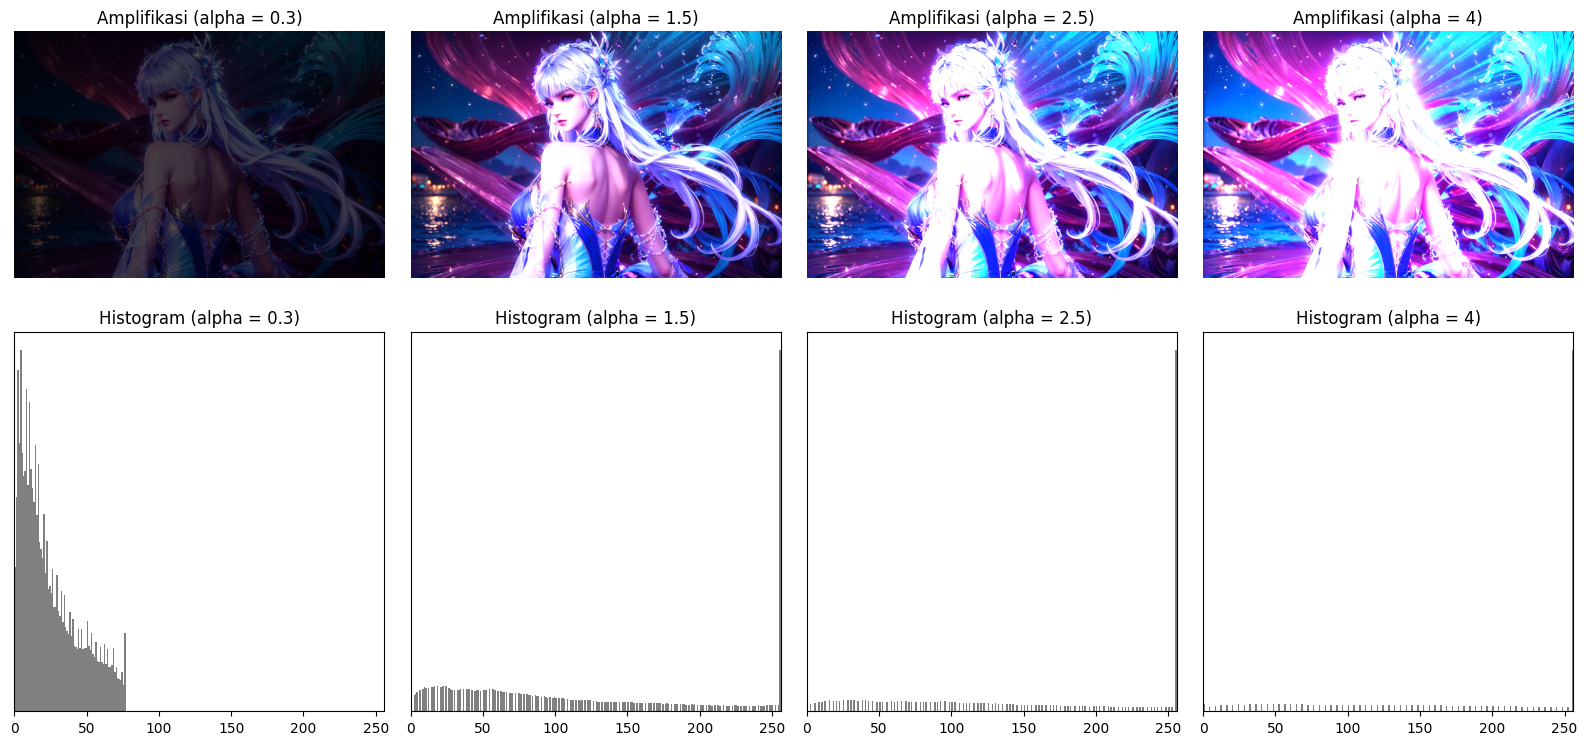

In [37]:
# OPERASI AMPLIFIKASI CITRA
alphas_citra = [0.3, 1.5, 2.5, 4]
plt.figure(figsize=(16, 8))

for idx, alpha in enumerate(alphas_citra):
    # Operasi Amplifikasi I'(i,j) = alpha * I(i,j)
    img_amp = cv2.convertScaleAbs(img1, alpha=alpha, beta=0)
    
    # Plot Citra Hasil Amplifikasi
    plt.subplot(2, 4, idx + 1)
    plt.imshow(img_amp)
    if alpha == 1:
        plt.title(f'Citra Asli (alpha = {alpha})')
    else:
        plt.title(f'Amplifikasi (alpha = {alpha})')
    plt.axis('off')
    
    # Plot Histogram
    plt.subplot(2, 4, idx + 5)
    plt.hist(img_amp.ravel(), bins=256, range=[0, 256], color='gray')
    plt.title(f'Histogram (alpha = {alpha})')
    plt.xlim([0, 256])
    plt.yticks([]) 

plt.tight_layout()
plt.show()

Analisis Perubahan Brightness dan Kontras:

Dari hasil plot, dapat dilihat bahwa amplifikasi secara langsung mengubah sebaran histogram. Ketika diperbesar ($\alpha > 1$), puncak histogram meregang dan bergeser ke kanan (mendekati 255), yang membuat gambar lebih terang (peningkatan brightness) dan kontrasnya meningkat (jarak antar warna makin lebar). Namun, jika berlebihan, banyak nilai pixel yang akan menumpuk di angka 255 akibat clipping.  
Jawaban Pertanyaan Analisis:

1. Efek $\alpha > 1$ pada citra: Nilai pixel menjadi lebih besar, sehingga citra terlihat lebih terang secara keseluruhan dan kontrasnya meningkat.

2. Efek $0 < \alpha < 1$ pada citra: Nilai pixel menjadi lebih kecil, sehingga histogram merapat ke kiri (mendekati 0). Citra akan terlihat lebih gelap, redup, dan kontrasnya menurun.

3. Mengapa nilai pixel perlu dibatasi pada rentang tertentu? Karena tipe data citra umumnya adalah integer 8-bit (uint8) yang batas maksimal kapabilitas perangkat keras dan format komputernya adalah dari 0 hingga 255. Jika melebihi rentang (misalnya 260) tanpa dibatasi (clipping), akan terjadi overflow di mana warna akan "memutar balik" (contoh: 260 menjadi 4), yang membuat citra rusak secara visual.

4. Hubungan amplifikasi citra dengan peningkatan brightness: Amplifikasi citra adalah operasi perkalian matematis yang memperbesar nilai intensitas tiap pixel secara proporsional. Secara visual, peningkatan nilai intensitas ini langsung diterjemahkan oleh layar kita sebagai peningkatan brightness atau kecerahan gambar.

VISUALISASI C.1: UJI HOMOGENITAS


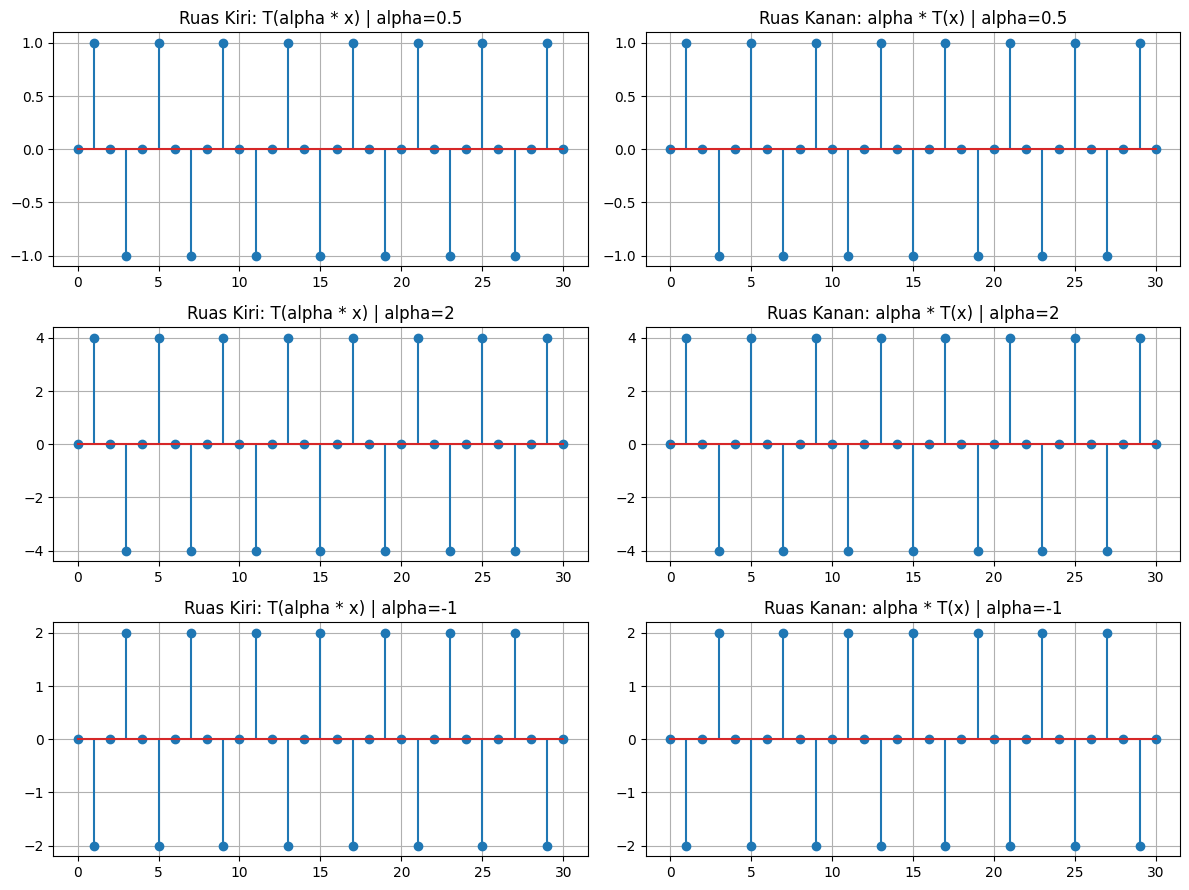

VISUALISASI C.2: UJI ADDITIVITAS


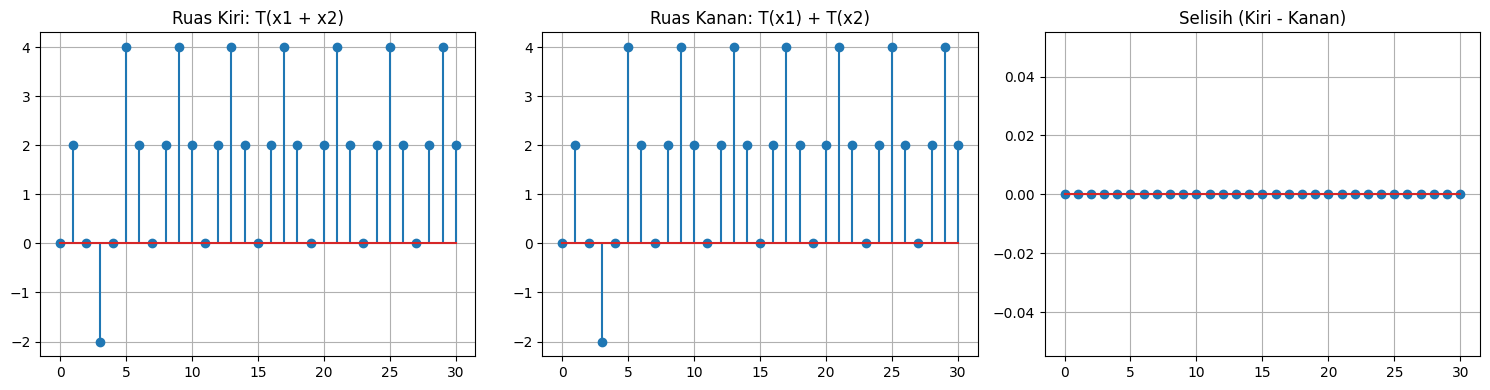

In [38]:
# UJI HOMOGENITAS SISTEM T(x) = 2x 
def T(x):
    return 2 * x
alphas_uji = [0.5, 2, -1]

print("VISUALISASI C.1: UJI HOMOGENITAS")
plt.figure(figsize=(12, 9))
for i, alpha in enumerate(alphas_uji):
    hasil_kiri = T(alpha * x1)
    hasil_kanan = alpha * T(x1)
    
    plt.subplot(3, 2, 2*i + 1)
    plt.stem(n, hasil_kiri)
    plt.title(f'Ruas Kiri: T(alpha * x) | alpha={alpha}')
    plt.grid(True)
    
    plt.subplot(3, 2, 2*i + 2)
    plt.stem(n, hasil_kanan)
    plt.title(f'Ruas Kanan: alpha * T(x) | alpha={alpha}')
    plt.grid(True)

plt.tight_layout()
plt.show()

# UJI ADDITIVITAS SISTEM T(x) = 2x 
print("VISUALISASI C.2: UJI ADDITIVITAS")

# Ruas Kiri: T(x1 + x2)
hasil_tambah_input = T(x1 + x2)
# Ruas Kanan: T(x1) + T(x2)
hasil_tambah_output = T(x1) + T(x2)
# Menghitung selisih antara ruas kiri dan kanan
selisih = hasil_tambah_input - hasil_tambah_output
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.stem(n, hasil_tambah_input)
plt.title('Ruas Kiri: T(x1 + x2)')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.stem(n, hasil_tambah_output)
plt.title('Ruas Kanan: T(x1) + T(x2)')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.stem(n, selisih)
plt.title('Selisih (Kiri - Kanan)')
plt.grid(True)

plt.tight_layout()
plt.show()

Kesimpulan Uji Sistem $T(x) = 2x$:

* Uji Homogenitas ($T(\alpha x) = \alpha T(x)$): Berdasarkan grafik perbandingan untuk nilai $\alpha = 0.5, 2$, dan $-1$, terlihat bahwa memproses sinyal yang sudah dikalikan dengan $\alpha$ menghasilkan output yang persis sama dengan mengalikan output sistem dengan $\alpha$. Oleh karena itu, sistem ini memenuhi sifat homogenitas.

* Uji Additivitas ($T(x_1 + x_2) = T(x_1) + T(x_2)$): Dari grafik perbandingan, plot ruas kiri dan ruas kanan menghasilkan bentuk amplitudo yang identik. Hal ini dibuktikan lebih lanjut oleh grafik selisih yang nilainya 0 di semua titik sampel $n$. Ini membuktikan bahwa memproses dua sinyal yang sudah dijumlahkan sama hasilnya dengan menjumlahkan hasil proses masing-masing sinyal secara terpisah. Oleh karena itu, sistem ini memenuhi sifat additivitas.

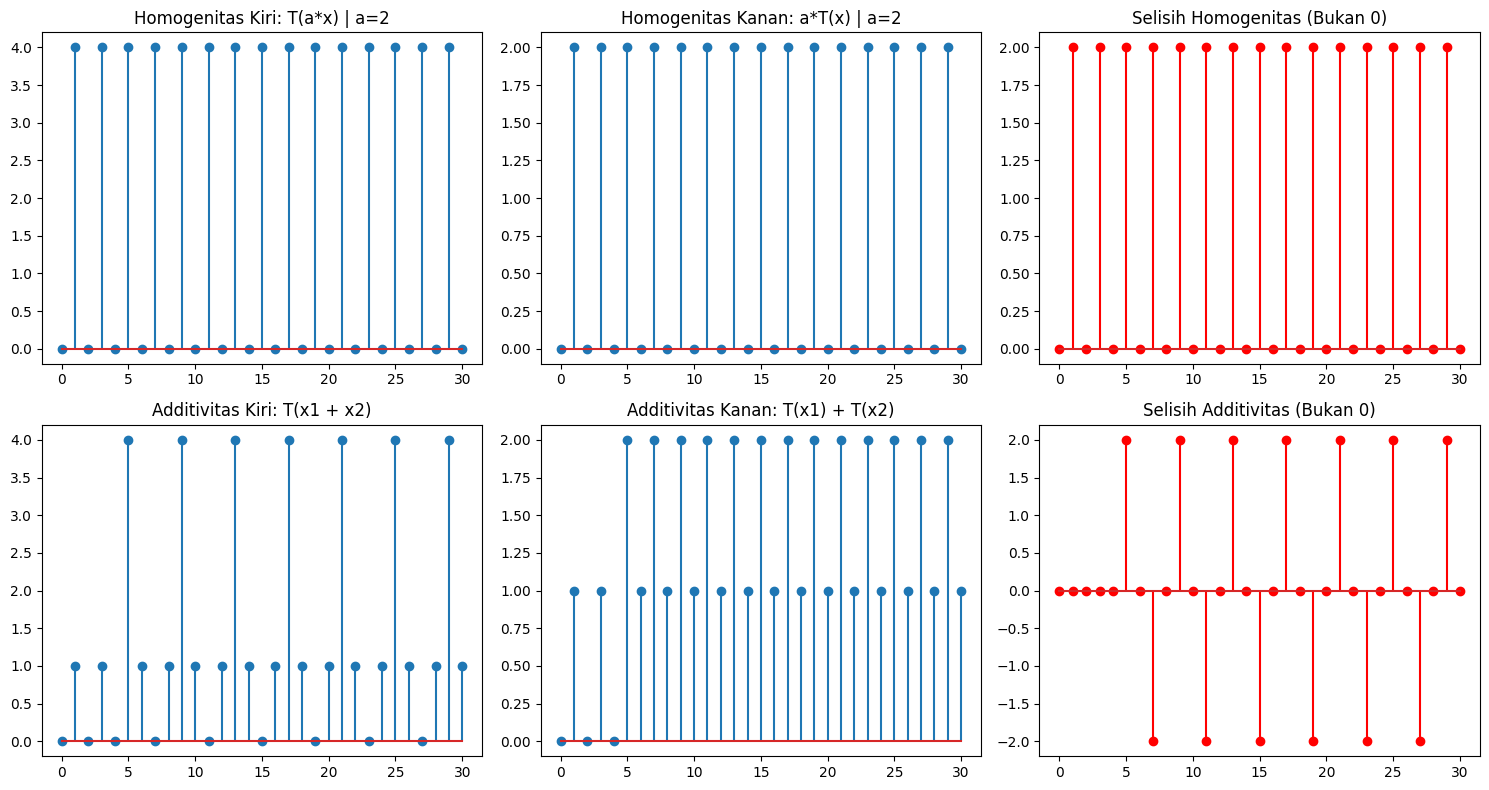

In [39]:
# UJI SISTEM NON-LINIER T2(x) = x^2
def T2(x):
    return x**2
alpha_uji = 2
# 1. Uji Homogenitas T2
kiri_homo = T2(alpha_uji * x1)       # T(alpha * x)
kanan_homo = alpha_uji * T2(x1)      # alpha * T(x)
selisih_homo = kiri_homo - kanan_homo
# 2. Uji Additivitas T2
kiri_addi = T2(x1 + x2)              # T(x1 + x2)
kanan_addi = T2(x1) + T2(x2)         # T(x1) + T(x2)
selisih_addi = kiri_addi - kanan_addi

# VISUALISASI BUKTI KEGAGALAN
plt.figure(figsize=(15, 8))

# Plot Homogenitas
plt.subplot(2, 3, 1)
plt.stem(n, kiri_homo)
plt.title(f'Homogenitas Kiri: T(a*x) | a={alpha_uji}')

plt.subplot(2, 3, 2)
plt.stem(n, kanan_homo)
plt.title(f'Homogenitas Kanan: a*T(x) | a={alpha_uji}')

plt.subplot(2, 3, 3)
plt.stem(n, selisih_homo, linefmt='r-', markerfmt='ro')
plt.title('Selisih Homogenitas (Bukan 0)')

# Plot Additivitas
plt.subplot(2, 3, 4)
plt.stem(n, kiri_addi)
plt.title('Additivitas Kiri: T(x1 + x2)')

plt.subplot(2, 3, 5)
plt.stem(n, kanan_addi)
plt.title('Additivitas Kanan: T(x1) + T(x2)')

plt.subplot(2, 3, 6)
plt.stem(n, selisih_addi, linefmt='r-', markerfmt='ro')
plt.title('Selisih Additivitas (Bukan 0)')

plt.tight_layout()
plt.show()

Jawaban Pertanyaan Analisis: 

1. Mengapa $T_1(x)=2x$ dapat disebut sistem linier?  Karena sistem ini murni hanya melakukan perkalian skalar konstan. Mengalikan input dengan $\alpha$ sebelum masuk sistem, atau mengalikan outputnya setelah keluar sistem, akan memberikan hasil yang ekuivalen.

2. Mengapa $T_2(x)=x^2$ bukan sistem linier?  Karena operasi pemangkatan merusak proporsionalitas. Jika input digandakan ($\alpha = 2$), outputnya tidak menjadi dua kali lipat, melainkan membesar secara eksponensial (menjadi empat kali lipat). Saat dua sinyal dijumlahkan sebelum dipangkatkan, akan muncul "komponen silang" (interferensi antar kedua sinyal) yang membuat sifat additivitasnya gagal mutlak.

3. Mengapa konsep sistem linier penting dalam DSP?  Karena sistem linier sifatnya sangat mudah diprediksi. Jika kita mengetahui bagaimana suatu filter memproses sinyal sederhana (seperti sinyal sinusoidal), kita bisa memprediksi dengan pasti bagaimana filter itu akan memproses suara manusia yang sangat kompleks, karena suara manusia pada dasarnya hanyalah gabungan dari banyak sinyal sinusoidal.

4. Apa hubungan sistem linier dengan superposisi?  Keduanya pada dasarnya adalah hal yang sama. Prinsip superposisi adalah istilah payung yang mencakup kombinasi dari sifat homogenitas (amplifikasi/skala) dan additivitas (penjumlahan). Suatu sistem dikatakan memenuhi prinsip superposisi jika dan hanya jika sistem tersebut linier. 

### Analisis Konseptual 

1. Dasar Superposisi: Operasi penjumlahan dan amplifikasi menjadi dasar superposisi karena prinsip superposisi secara definitif adalah gabungan dari sifat additivitas (penjumlahan dua sinyal) dan homogenitas (amplifikasi/perkalian skalar terhadap sinyal).

2. Tidak Semua Operasi Linier: Operasi seperti pemangkatan, nilai mutlak, atau logaritma tidak linier karena mereka merusak proporsionalitas. Menggandakan input pada sistem non-linier tidak akan menghasilkan output yang sekadar dua kali lipat, melainkan membesar secara eksponensial atau berubah bentuk.

3. Dampak Sistem Tidak Linier: Jika suatu sistem tidak linier, hasil pemrosesannya menjadi sangat sulit diprediksi secara matematis. Sistem akan memunculkan komponen frekuensi baru (harmonic distortion) yang sebelumnya tidak ada pada sinyal asli, sehingga sinyal asal bisa rusak atau terdistorsi parah.

4. Pentingnya Shift dan Amplify: Kedua operasi ini merepresentasikan parameter dunia nyata secara langsung. Shift merepresentasikan jarak, posisi ruang, atau waktu tempuh (delay), sementara amplify merepresentasikan energi, intensitas suara (volume), atau tingkat pencahayaan (brightness).

### Analisis Aplikasi Nyata: 
Augmentasi Data Citra 

1. Masalah: Keterbatasan jumlah data latih (dataset) yang membuat model kecerdasan buatan rentan menghafal data (overfitting) alih-alih belajar mengenali pola.

2. Operasi yang Digunakan: Operasi penggeseran (translasi) untuk memindah letak objek, dan amplifikasi untuk mengubah kecerahan gambar.

3. Relevansi: Operasi ini secara artifisial melipatgandakan dataset yang ada dengan menciptakan variasi seolah-olah gambar diambil dari sudut atau pencahayaan yang berbeda.

4. Linieritas: Operasi translasi matriks dan perkalian intensitas pixel secara matematis tergolong operasi linier.

5. Kelebihan & Keterbatasan: Kelebihannya adalah sangat murah secara komputasi dan efektif meningkatkan akurasi model. Keterbatasannya adalah jika penggeseran terlalu ekstrem, fitur penting (region of interest) pada citra bisa terpotong dan keluar dari frame.

### Skenario Pengambilan Keputusan

* Skenario 1 (Image Blending): Langkah mutlak yang harus dilakukan adalah melakukan resizing agar dimensi matriks kedua citra persis sama. Alasannya, operasi penjumlahan citra adalah penjumlahan elemen-per-elemen secara koordinat matriks.

* Skenario 2 (Audio Kecil): Operasi yang dilakukan adalah amplifikasi dengan faktor $\alpha > 1$. Risikonya, jika $\alpha$ terlalu besar, akan terjadi clipping di mana amplitudo sinyal menabrak batas maksimal sistem yang menyebabkan suara terdengar pecah atau terdistorsi.

* Skenario 3 (Deteksi Objek): Penggeseran membantu menciptakan banyak variasi posisi objek di berbagai sudut frame dari satu gambar asal. Ini melatih sistem untuk tidak terpaku pada koordinat letak objek, melainkan fokus pada fitur visual objeknya (translation invariance).

* Skenario 4 (Tukar Urutan Filter): Sistem tersebut dipastikan TIDAK linier. Salah satu sifat utama dari sistem linier yang dipasang berurutan (cascade) adalah sifat komutatif, di mana mengubah urutan blok sistem tidak akan mengubah hasil akhirnya.